Exploration des données puis traitement : exploration -> nettoyage -> renormalisation 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from dtaidistance import dtw
print(dtw.try_import_c())

True


In [3]:
df_logs = pd.read_parquet("logs.parquet")

print("\n--- APERÇU DES DONNÉES ---")
print(df_logs.head())

print("\n--- DIMENSIONS ---")
print(f"Lignes : {df_logs.shape[0]}")
print(f"Colonnes : {df_logs.shape[1]}")

print("\n--- COLONNES ---")
print(df_logs.columns.tolist())

print("\n--- TYPES DE DONNÉES ---")
print(df_logs.dtypes)

print("\n--- VALEURS MANQUANTES ---")
print(df_logs.isna().sum())

print("\n--- STATISTIQUES DESCRIPTIVES ---")
print(df_logs.describe(include="all"))

df_tops = pd.read_parquet("tops.parquet")

print("\n--- APERÇU DES DONNÉES ---")
print(df_tops.head())

print("\n--- DIMENSIONS ---")
print(f"Lignes : {df_tops.shape[0]}")
print(f"Colonnes : {df_tops.shape[1]}")

print("\n--- COLONNES ---")
print(df_tops.columns.tolist())

print("\n--- TYPES DE DONNÉES ---")
print(df_tops.dtypes)

print("\n--- VALEURS MANQUANTES ---")
print(df_tops.isna().sum())

print("\n--- STATISTIQUES DESCRIPTIVES ---")
print(df_tops.describe(include="all"))



--- APERÇU DES DONNÉES ---
      wellName  DEPTH        GR
1  512320698.0  421.0   96.9752
2  512320698.0  421.5  102.3324
3  512320698.0  422.0  104.6432
4  512320698.0  422.5   99.2187
5  512320698.0  423.0   92.0200

--- DIMENSIONS ---
Lignes : 7698162
Colonnes : 3

--- COLONNES ---
['wellName', 'DEPTH', 'GR']

--- TYPES DE DONNÉES ---
wellName    float64
DEPTH       float64
GR          float64
dtype: object

--- VALEURS MANQUANTES ---
wellName    0
DEPTH       0
GR          0
dtype: int64

--- STATISTIQUES DESCRIPTIVES ---
           wellName         DEPTH            GR
count  7.698162e+06  7.698162e+06  7.698162e+06
mean   5.123274e+08  3.726369e+03  7.280153e+01
std    3.354847e+03  1.859567e+03  5.715067e+02
min    5.123207e+08  1.000000e+00 -9.999000e+03
25%    5.123250e+08  2.120500e+03  9.269270e+01
50%    5.123267e+08  3.724500e+03  1.028935e+02
75%    5.123305e+08  5.328000e+03  1.136231e+02
max    5.123363e+08  8.940500e+03  2.052933e+03

--- APERÇU DES DONNÉES ---
      

Logs (données continues)  
Mesures enregistrées en continu le long du puits (ex : GR, densité, résistivité).
→ Très volumineux, réguliers, parfois avec valeurs sentinelles (ex : -9999).

Tops (données ponctuelles)  
Profondeurs où un horizon géologique est identifié (ex : MARCEL, CONRAD…).
→ Peu de lignes, valeurs manquantes possibles.

In [4]:
df_logs = df_logs.sort_values(by=['wellName', 'DEPTH']).reset_index(drop=True)
df_logs['step'] = df_logs.groupby('wellName')['DEPTH'].diff()
df_logs['step'].value_counts()
df_logs.groupby('wellName')['step'].value_counts()

wellName     step
512320698.0  0.5     12841
512320699.0  0.5     12769
512320928.0  0.5     13165
512320970.0  0.5     13211
512320971.0  0.5     13207
                     ...  
512334042.0  0.5     13219
512334043.0  0.5     12831
512335135.0  0.5     13269
512335370.0  0.5     17480
512336327.0  0.5     13005
Name: count, Length: 615, dtype: int64

Les données sont régulières, pas besoin de faire de l'interpolation ou de changer les steps ici

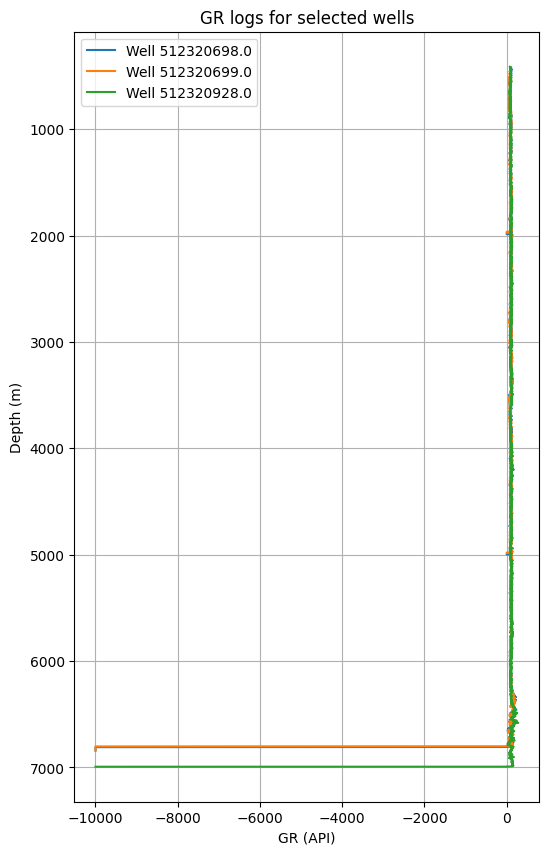

In [5]:
wells_to_plot = df_logs['wellName'].unique()[:3]
plt.figure(figsize=(6, 10))

for well in wells_to_plot:
    subset = df_logs[df_logs['wellName'] == well]
    plt.plot(subset['GR'], subset['DEPTH'], label=f"Well {well}")

plt.gca().invert_yaxis()  # profondeur vers le bas
plt.xlabel("GR (API)")
plt.ylabel("Depth (m)")
plt.title("GR logs for selected wells")
plt.legend()
plt.grid(True)
plt.show()

Les valeurs extrêmes polluent notre compréhension des données, filtrons les en ne gardant que les valeurs entre 0 et 400 disons, ce qui semble généreux au vu des stats descriptives

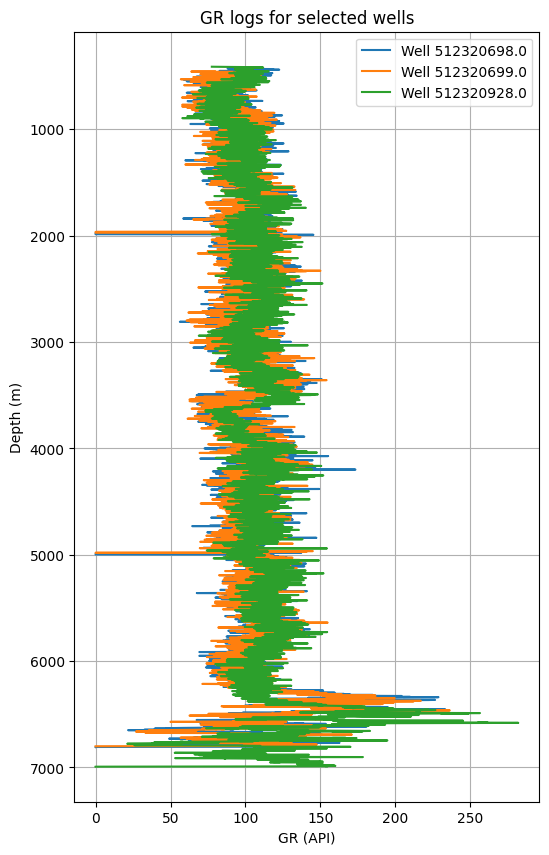

In [6]:
df_logs.loc[df_logs['GR'] < 0, 'GR'] = pd.NA
df_logs.loc[df_logs['GR'] > 400, 'GR'] = pd.NA
df_logs = df_logs.dropna(subset=['GR'])
plt.figure(figsize=(6, 10))

for well in wells_to_plot:
    subset = df_logs[df_logs['wellName'] == well]
    plt.plot(subset['GR'], subset['DEPTH'], label=f"Well {well}")

plt.gca().invert_yaxis()  # profondeur vers le bas
plt.xlabel("GR (API)")
plt.ylabel("Depth (m)")
plt.title("GR logs for selected wells")
plt.legend()
plt.grid(True)
plt.show()

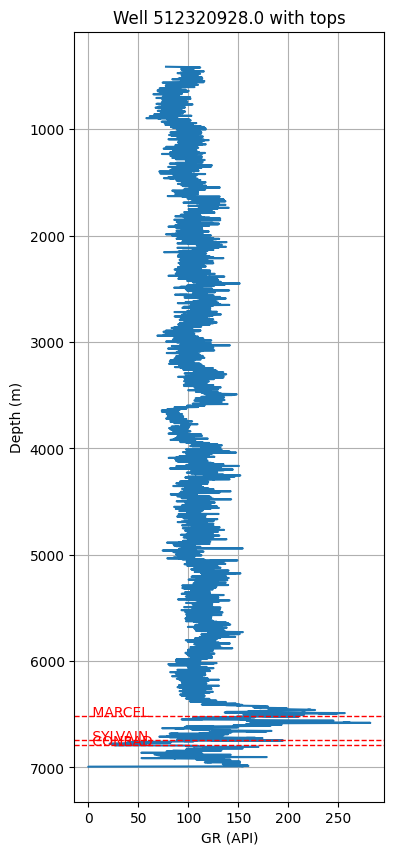

In [7]:
df_tops = df_tops.reset_index()
def plot_well_with_tops(well):
    # Extraire les données du puits
    log = df_logs[df_logs['wellName'] == well]
    tops = df_tops[df_tops['wellName'] == well]

    plt.figure(figsize=(4, 10))

    # Tracer le log GR
    plt.plot(log['GR'], log['DEPTH'], label='GR')

    # Superposer les tops
    if not tops.empty:
        for horizon in ['MARCEL', 'CONRAD', 'SYLVAIN']:
            depth = tops[horizon].values[0]
            if not pd.isna(depth):
                plt.axhline(depth, color='red', linestyle='--', linewidth=1)
                plt.text(log['GR'].min(), depth, f' {horizon}', color='red')

    plt.gca().invert_yaxis()
    plt.xlabel("GR (API)")
    plt.ylabel("Depth (m)")
    plt.title(f"Well {well} with tops")
    plt.grid(True)
    plt.show()

# Exemple : tracer un puit
plot_well_with_tops(wells_to_plot[2])

On comprend mieux ce que l'on recherche : pouvoir prédire à partir de nos puits annotés les marqueurs géologiques Marcel, Sylvain et Conrad pour des puits non annotés par des géologues

In [8]:
def dtw_with_path(x, y):
    n, m = len(x), len(y)
    
    # Matrice de coût local
    C = np.abs(x[:, None] - y[None, :])
    
    # Matrice de coût cumulé
    D = np.zeros((n, m))
    D[0, 0] = C[0, 0]
    
    # Remplissage première ligne / colonne
    for i in range(1, n):
        D[i, 0] = C[i, 0] + D[i-1, 0]
    for j in range(1, m):
        D[0, j] = C[0, j] + D[0, j-1]
    
    # Remplissage général
    for i in range(1, n):
        for j in range(1, m):
            D[i, j] = C[i, j] + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    
    # Backtracking du chemin
    i, j = n-1, m-1
    path = [(i, j)]
    
    while i > 0 or j > 0:
        moves = []
        if i > 0:
            moves.append((D[i-1, j], i-1, j))
        if j > 0:
            moves.append((D[i, j-1], i, j-1))
        if i > 0 and j > 0:
            moves.append((D[i-1, j-1], i-1, j-1))
        
        cost, i, j = min(moves)
        path.append((i, j))
    
    path.reverse()
    return D[-1, -1], path


DTW distance : 0.0
Chemin d'alignement :
[(0, 0), (1, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6)]


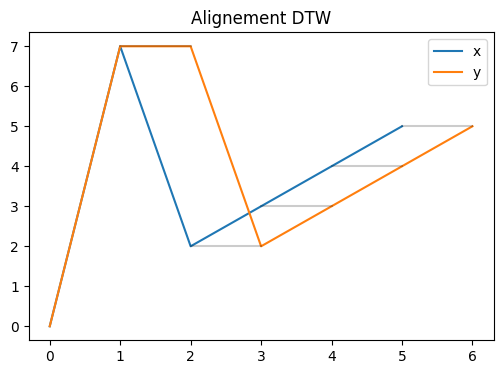

In [9]:
# Série de référence
x = np.array([0, 7, 2, 3, 4, 5])

# Série décalée et étirée
y = np.array([0, 7, 7, 2, 3, 4, 5])

dist, path = dtw_with_path(x, y)

print("DTW distance :", dist)
print("Chemin d'alignement :")
print(path)

plt.figure(figsize=(6,4))
plt.plot(x, label="x")
plt.plot(y, label="y")
for (i,j) in path:
    plt.plot([i, j], [x[i], y[j]], 'k-', alpha=0.2)
plt.legend()
plt.title("Alignement DTW")
plt.show()

In [10]:
well_A = 512320698.0   # annoté
well_B = 512332207.0   # à prédire

In [11]:
def get_log(well):
    sub = df_logs[df_logs['wellName'] == well]
    return sub['GR'].values, sub['DEPTH'].values

x, depth_x = get_log(well_A)
y, depth_y = get_log(well_B)

dist, path = dtw_with_path(x, y)

print("DTW distance :", dist)
print("Longueur du chemin :", len(path))

DTW distance : 114802.33543911821
Longueur du chemin : 21877


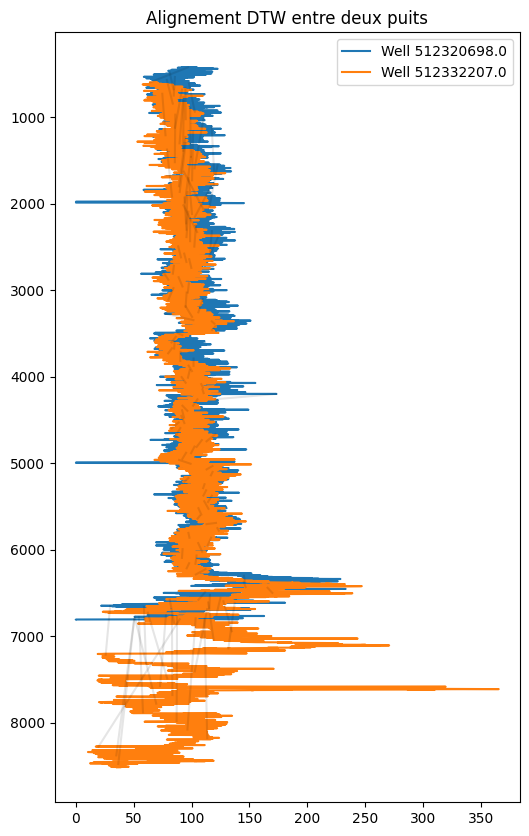

In [12]:
plt.figure(figsize=(6,10))
plt.plot(x, depth_x, label=f"Well {well_A}")
plt.plot(y, depth_y, label=f"Well {well_B}")

for (i, j) in path[::200]:  # on échantillonne pour alléger l'affichage
    plt.plot([x[i], y[j]], [depth_x[i], depth_y[j]], 'k-', alpha=0.1)

plt.gca().invert_yaxis()
plt.legend()
plt.title("Alignement DTW entre deux puits")
plt.show()

L'alignement est intéressant mais le calcul de DTW est particulièrement lent... Etant donné que l'on a quand même des puits pas trop étirés les uns par rapport aux autres de ce qu'on a vu dans les visualisations, on va limiter la recherche de chemin dans un voisinage autour de chaque profondeur par exemple 1000 ou 500 plutôt que de regarder toutes les autres profondeurs accessibles théoriquement

In [13]:
def dtw_with_band(x, y, w=500):
    """
    DTW avec bande de Sakoe–Chiba de largeur w.
    x, y : séries 1D
    w : largeur de la bande (en nombre d'échantillons)
    """
    n, m = len(x), len(y)
    
    # Bande maximale : on ne peut pas dépasser les dimensions
    w = max(w, abs(n - m))

    # Matrice de coût cumulée initialisée à +inf
    D = np.full((n, m), np.inf)
    
    # Initialisation
    D[0, 0] = abs(x[0] - y[0])
    
    # Calcul dans la bande
    for i in range(1, n):
        # Limites de j dans la bande
        j_start = max(1, i - w)
        j_end   = min(m, i + w)
        
        for j in range(j_start, j_end):
            cost = abs(x[i] - y[j])
            D[i, j] = cost + min(
                D[i-1, j],     # vertical
                D[i, j-1],     # horizontal
                D[i-1, j-1]    # diagonal
            )
    
    # Backtracking du chemin
    i, j = n-1, m-1
    path = [(i, j)]
    
    while i > 0 or j > 0:
        candidates = []
        if i > 0 and D[i-1, j] != np.inf:
            candidates.append((D[i-1, j], i-1, j))
        if j > 0 and D[i, j-1] != np.inf:
            candidates.append((D[i, j-1], i, j-1))
        if i > 0 and j > 0 and D[i-1, j-1] != np.inf:
            candidates.append((D[i-1, j-1], i-1, j-1))
        
        if not candidates:
            break
        
        _, i, j = min(candidates)
        path.append((i, j))
    
    path.reverse()
    return D[-1, -1], path


In [14]:
dist, path = dtw_with_band(x, y)

print("DTW distance :", dist)
print("Longueur du chemin :", len(path))

DTW distance : inf
Longueur du chemin : 21877


Nouveau calcul 10s vs 2min avant et la distance n'a changé que de 0.04% (dans le premier tets, de rien dans le second), en plus on évite que le chemin suive un alignement aberrant, on garde cette fonction

In [15]:
def predict_top_from_dtw(path, depth_x, depth_y, top_A):
    """
    path : liste de couples (i, j) du DTW
    depth_x : profondeurs du puits A
    depth_y : profondeurs du puits B
    top_A : profondeur du top dans le puits A
    """
    # indice du top dans A
    idx_A = np.argmin(np.abs(depth_x - top_A))
    
    # tous les j alignés avec cet i
    aligned_js = [j for (i, j) in path if i == idx_A]
    if len(aligned_js) == 0:
        return None
    
    idx_B = int(np.mean(aligned_js))
    return depth_y[idx_B]

tops_A = df_tops[df_tops['wellName'] == well_A].iloc[0]

# prédire les tops du puits B
predicted_tops_B = {}
for horizon in ['MARCEL', 'CONRAD', 'SYLVAIN']:
    top_A = tops_A[horizon]
    if not pd.isna(top_A):
        predicted_tops_B[horizon] = predict_top_from_dtw(path, depth_x, depth_y, top_A)
    else:
        predicted_tops_B[horizon] = None

print(predicted_tops_B)

print(df_tops[df_tops['wellName'] == well_B].iloc[0])

{'MARCEL': np.float64(6458.0), 'CONRAD': np.float64(7312.0), 'SYLVAIN': np.float64(7201.5)}
wellName    512332207.0
MARCEL              NaN
CONRAD           6732.0
SYLVAIN             NaN
Name: 532, dtype: float64


Ca marche presque parfaitement pour Marcel et Conrad et ce n'est pas top pour Sylvain (deux tests). Pour améliorer ce résultat, je propose d'essayer de renormaliser les séries

In [16]:
def get_log_normalized(well):
    sub = df_logs[df_logs['wellName'] == well]
    if sub.empty:
        print(f"⚠️ Aucun log trouvé pour le puits {well}")
        return np.array([]), np.array([])
    
    gr = sub['GR'].values.astype(float)
    depth = sub['DEPTH'].values.astype(float)
    
    # Normalisation min-max
    gr_norm = (gr - gr.min()) / (gr.max() - gr.min())
    
    return gr_norm, depth

In [17]:
# 1. extraire les logs normalisés
x, depth_x = get_log_normalized(well_A)
y, depth_y = get_log_normalized(well_B)

# 2. DTW rapide avec bande
w = 300
dist, path = dtw_with_band(x, y, w)

# 3. prédire les tops
predicted_tops_B = {}
tops_A = df_tops[df_tops['wellName'] == well_A].iloc[0]

for horizon in ['MARCEL', 'CONRAD', 'SYLVAIN']:
    top_A = tops_A[horizon]
    if not pd.isna(top_A):
        predicted_tops_B[horizon] = predict_top_from_dtw(path, depth_x, depth_y, top_A)
    else:
        predicted_tops_B[horizon] = None

In [18]:
print(predicted_tops_B)
print(df_tops[df_tops['wellName'] == well_B].iloc[0])

{'MARCEL': np.float64(7112.5), 'CONRAD': np.float64(7582.0), 'SYLVAIN': np.float64(7200.0)}
wellName    512332207.0
MARCEL              NaN
CONRAD           6732.0
SYLVAIN             NaN
Name: 532, dtype: float64


C'est mieux pour Sylvain ! Et il n'a fallu qu'un unique puit annoté pour pouvoir transmettre les résultats à un deuxième puit. Pour pouvoir l'appliquer à tous nos puits pour mieux mesurer la fiabilité de cet algo, on peut utiliser la bibliothèque associée à DTW pour que les calculs soient plus rapides.

In [19]:
# 2. DTW rapide avec bande
path = dtw.warping_path(x, y, window=300)
print((len(x),len(y)))

# 3. prédire les tops
predicted_tops_B = {}
tops_A = df_tops[df_tops['wellName'] == well_A].iloc[0]

for horizon in ['MARCEL', 'CONRAD', 'SYLVAIN']:
    top_A = tops_A[horizon]
    predicted_tops_B[horizon] = predict_top_from_dtw(path, depth_x, depth_y, top_A)

print(predicted_tops_B)
print(df_tops[df_tops['wellName'] == well_B].iloc[0])

(12775, 15833)
{'MARCEL': np.float64(7112.5), 'CONRAD': np.float64(7582.0), 'SYLVAIN': np.float64(7200.0)}
wellName    512332207.0
MARCEL              NaN
CONRAD           6732.0
SYLVAIN             NaN
Name: 532, dtype: float64


ça prend plus de temps ?? c'est étonnant

In [25]:
# Tous les puits pour lesquels on a des tops
all_wells = df_tops["wellName"].unique()

# On mélange et on en prend 20
np.random.seed(0)  # pour la reproductibilité
selected_wells = np.random.choice(all_wells, size=20, replace=False)

# Puits de référence = le premier
well_A = selected_wells[0]
wells_B = selected_wells[1:20]

print("Puits de référence :", well_A)
print("Puits test :", wells_B)


Puits de référence : 512330153.0
Puits test : [5.12324327e+08 5.12325824e+08 5.12331063e+08 5.12325739e+08
 5.12332887e+08 5.12330130e+08 5.12331895e+08 5.12330330e+08
 5.12325134e+08 5.12326808e+08 5.12329264e+08 5.12325209e+08
 5.12326409e+08 5.12323072e+08 5.12330513e+08 5.12331102e+08
 5.12323910e+08 5.12325491e+08 5.12327285e+08]


In [26]:
results = []

# log du puits de référence
x, depth_x = get_log_normalized(well_A)
tops_A = df_tops[df_tops["wellName"] == well_A].iloc[0]

for well_B in wells_B:
    y, depth_y = get_log_normalized(well_B)
    if len(x) == 0 or len(y) == 0:
        continue  # on saute si pas de log

    # DTW avec bande (ta version maison)
    dist, path = dtw_with_band(x, y, w=300)

    tops_B_true = df_tops[df_tops["wellName"] == well_B].iloc[0]

    # prédiction + erreurs
    for horizon in ["MARCEL", "CONRAD", "SYLVAIN"]:
        top_A = tops_A[horizon]
        top_B_true = tops_B_true[horizon]

        if pd.isna(top_A) or pd.isna(top_B_true):
            continue

        top_B_pred = predict_top_from_dtw(path, depth_x, depth_y, top_A)
        if top_B_pred is None:
            continue

        err = top_B_pred - top_B_true

        results.append({
            "well": well_B,
            "horizon": horizon,
            "true_depth": top_B_true,
            "pred_depth": top_B_pred,
            "error": err,
            "abs_error": abs(err),
        })

df_errors = pd.DataFrame(results)
df_errors.head()


,well,horizon,true_depth,pred_depth,error,abs_error
0,512324327.0,MARCEL,5938.0,5925.5,-12.5,12.5
1,512324327.0,CONRAD,6218.0,6811.5,593.5,593.5
2,512324327.0,SYLVAIN,6180.0,6662.5,482.5,482.5
3,512325824.0,MARCEL,6298.0,6276.0,-22.0,22.0
4,512325824.0,CONRAD,6549.0,6549.0,0.0,0.0


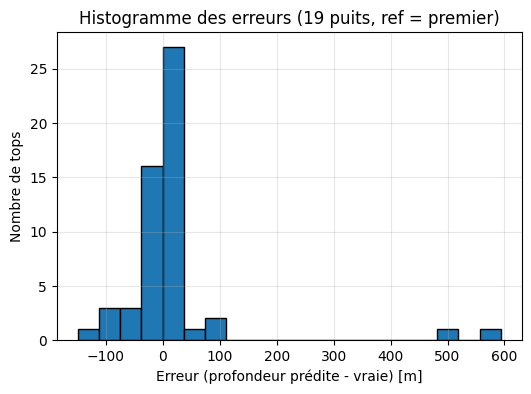

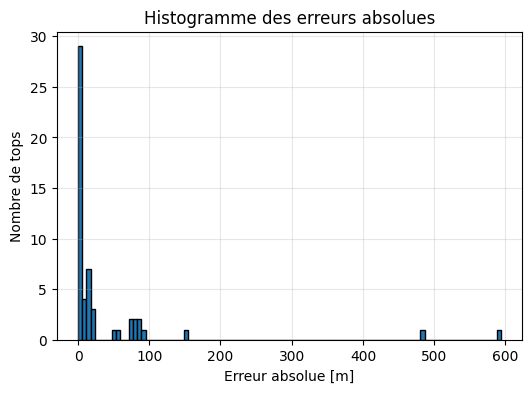

In [27]:
plt.figure(figsize=(6,4))
plt.hist(df_errors["error"], bins=20, edgecolor="k")
plt.xlabel("Erreur (profondeur prédite - vraie) [m]")
plt.ylabel("Nombre de tops")
plt.title("Histogramme des erreurs (19 puits, ref = premier)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df_errors["abs_error"], bins=100, edgecolor="k")
plt.xlabel("Erreur absolue [m]")
plt.ylabel("Nombre de tops")
plt.title("Histogramme des erreurs absolues")
plt.grid(True, alpha=0.3)
plt.show()


DTW  montre des valeurs aberrantes >100, et n'est pas très bon tout le temps avec pas mal de valeurs avec une erreur de plus de 30...

In [28]:
# Trouver la ligne avec l'erreur absolue maximale
worst = df_errors.loc[df_errors["abs_error"].idxmax()]
worst


well          512324327.0
horizon            CONRAD
true_depth         6218.0
pred_depth         6811.5
error               593.5
abs_error           593.5
Name: 1, dtype: object

In [29]:
worst_well = worst["well"]
worst_horizon = worst["horizon"]

print("Puits problématique :", worst_well)
print("Horizon concerné :", worst_horizon)


Puits problématique : 512324327.0
Horizon concerné : CONRAD


In [30]:
# Logs du puits de référence
x, depth_x = get_log_normalized(well_A)

# Logs du puits problématique
y, depth_y = get_log_normalized(worst_well)

# DTW (ta version maison)
dist, path = dtw_with_band(x, y, w=300)

# Tops du puits A et du puits problématique
tops_A = df_tops[df_tops["wellName"] == well_A].iloc[0]
tops_B_true = df_tops[df_tops["wellName"] == worst_well].iloc[0]

# Prédiction des tops
predicted = {}
for horizon in ["MARCEL", "CONRAD", "SYLVAIN"]:
    predicted[horizon] = predict_top_from_dtw(path, depth_x, depth_y, tops_A[horizon])


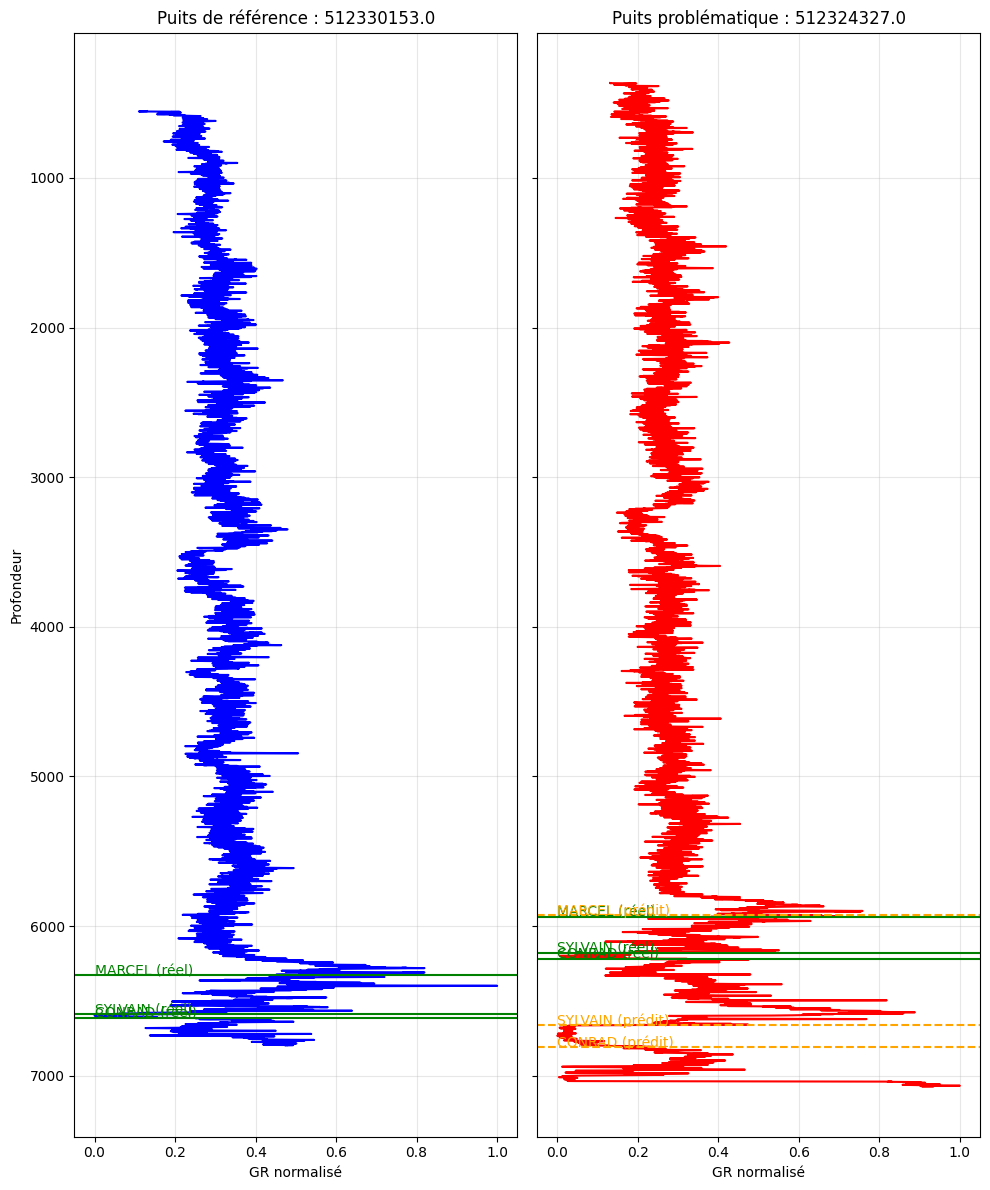

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 12), sharey=True)

# --- Puits de référence ---
ax = axes[0]
ax.plot(x, depth_x, color="blue")
ax.set_title(f"Puits de référence : {well_A}")
ax.set_xlabel("GR normalisé")
ax.set_ylabel("Profondeur")

for horizon in ["MARCEL", "CONRAD", "SYLVAIN"]:
    d = tops_A[horizon]
    if not pd.isna(d):
        ax.axhline(d, color="green", linewidth=1.5)
        ax.text(min(x), d, f"{horizon} (réel)", color="green")

ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# --- Puits problématique ---
ax = axes[1]
ax.plot(y, depth_y, color="red")
ax.set_title(f"Puits problématique : {worst_well}")
ax.set_xlabel("GR normalisé")

# Tops réels
for horizon in ["MARCEL", "CONRAD", "SYLVAIN"]:
    d = tops_B_true[horizon]
    if not pd.isna(d):
        ax.axhline(d, color="green", linewidth=1.5)
        ax.text(min(y), d, f"{horizon} (réel)", color="green")

# Tops prédits
for horizon in ["MARCEL", "CONRAD", "SYLVAIN"]:
    d = predicted[horizon]
    if d is not None:
        ax.axhline(d, color="orange", linestyle="--", linewidth=1.5)
        ax.text(min(y), d, f"{horizon} (prédit)", color="orange")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


On est clairement face à un outlier. Je pense à deux options : on peut essayer de classer par zones géologiques pour réduire  l'incertitude (de la surface à Marcel puis de Marcel à Sylvain etc.) ou on peut avoir plusieurs puits de références en ajoutant les outliers à nos puits de référence pour être sûr de capturer toute la complexité de notre géologie, plus qu'à choisir le puit de référence le plus proche au sens de la DTW pour décider pour chaque puit à prédire quel sera le puit parmi ceux de référence utilisés.

Choisir 𝑘 puits de référence de sorte que la corrélation minimale entre un puits quelconque et son meilleur puits de référence soit maximisée.

In [32]:
wells = df_tops["wellName"].unique()
np.random.seed(0)  # reproductible
subset_wells = np.random.choice(wells, size=50, replace=False)
wells = subset_wells
n = len(wells)
C = np.full((n, n), np.nan)

def get_log_normalized(well):
    sub = df_logs[df_logs["wellName"] == well]

    if sub.empty:
        return np.array([]), np.array([])

    depth = sub["DEPTH"].values.astype(float)
    gr = sub["GR"].values.astype(float)

    # Nettoyage
    mask = ~np.isnan(depth) & ~np.isnan(gr)
    depth = depth[mask]
    gr = gr[mask]

    if len(gr) == 0:
        return np.array([]), np.array([])

    # Normalisation min-max
    gmin, gmax = gr.min(), gr.max()
    if gmax > gmin:
        gr_norm = (gr - gmin) / (gmax - gmin)
    else:
        gr_norm = np.zeros_like(gr)

    return np.ascontiguousarray(gr_norm), np.ascontiguousarray(depth)

for i, wi in enumerate(wells):
    xi, _ = get_log_normalized(wi)
    for j, wj in enumerate(wells):
        if j < i:
            continue
        xj, _ = get_log_normalized(wj)
        m = min(len(xi), len(xj))
        if m < 200:
            continue
        c = np.corrcoef(xi[:m], xj[:m])[0, 1]
        C[i, j] = C[j, i] = c
    
D = 1 - C

In [33]:
def choose_reference_wells(D, wells, k):
    n = len(wells)
    refs_idx = []

    # 1) premier puits = celui avec la plus petite distance moyenne
    mean_dist = np.nanmean(D, axis=1)
    first = np.nanargmin(mean_dist)
    refs_idx.append(first)

    # 2) ajouter les k-1 puits les plus mal couverts
    for _ in range(k - 1):
        dist_to_refs = np.nanmin(D[:, refs_idx], axis=1)
        next_ref = np.nanargmax(dist_to_refs)
        refs_idx.append(next_ref)

    return [wells[i] for i in refs_idx]

In [34]:
reference_wells = choose_reference_wells(D, wells, k=5)
reference_wells

[np.float64(512331063.0),
 np.float64(512324327.0),
 np.float64(512322063.0),
 np.float64(512320980.0),
 np.float64(512325651.0)]

Maintenant testons à nouveau avec une liste de puits de référence

In [35]:
np.random.seed(0)
test_wells = np.random.choice(df_tops["wellName"].unique(), size=20, replace=False)

In [36]:
def best_reference_for(well_B, reference_wells):
    best_corr = -np.inf
    best_ref = None

    y, _ = get_log_normalized(well_B)

    for well_A in reference_wells:
        x, _ = get_log_normalized(well_A)
        m = min(len(x), len(y))
        if m < 200:
            continue
        corr = np.corrcoef(x[:m], y[:m])[0, 1]
        if corr > best_corr:
            best_corr = corr
            best_ref = well_A

    return best_ref, best_corr

In [37]:
results = []

for well_B in test_wells:
    # Trouver le meilleur puits de référence
    best_ref, corr = best_reference_for(well_B, reference_wells)

    if best_ref is None:
        continue

    # Récupérer logs
    x, depth_x = get_log_normalized(best_ref)
    y, depth_y = get_log_normalized(well_B)

    # DTW avec bande
    dist, path = dtw_with_band(x, y, w=300)

    # Tops réels
    tops_A = df_tops[df_tops["wellName"] == best_ref].iloc[0]
    tops_B_true = df_tops[df_tops["wellName"] == well_B].iloc[0]

    # Prédictions
    for horizon in ["MARCEL", "CONRAD", "SYLVAIN"]:
        if pd.isna(tops_A[horizon]) or pd.isna(tops_B_true[horizon]):
            continue

        pred = predict_top_from_dtw(path, depth_x, depth_y, tops_A[horizon])
        if pred is None:
            continue

        err = pred - tops_B_true[horizon]

        results.append({
            "well": well_B,
            "ref": best_ref,
            "corr": corr,
            "horizon": horizon,
            "true": tops_B_true[horizon],
            "pred": pred,
            "error": err,
            "abs_error": abs(err)
        })

df_eval = pd.DataFrame(results)
df_eval.head()


,well,ref,corr,horizon,true,pred,error,abs_error
0,512330153.0,512331063.0,0.366841,MARCEL,6328.0,6333.5,5.5,5.5
1,512330153.0,512331063.0,0.366841,CONRAD,6614.0,6615.5,1.5,1.5
2,512330153.0,512331063.0,0.366841,SYLVAIN,6589.0,6578.0,-11.0,11.0
3,512324327.0,512324327.0,1.000000,MARCEL,5938.0,5938.0,0.0,0.0
4,512324327.0,512324327.0,1.000000,CONRAD,6218.0,6218.0,0.0,0.0


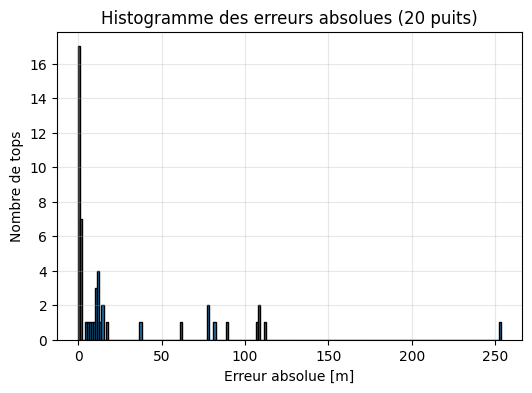

Moyenne abs_error : 25.68
Médiane abs_error : 5.50


In [39]:
plt.figure(figsize=(6,4))
plt.hist(df_eval["abs_error"], bins=200, edgecolor="k")
plt.xlabel("Erreur absolue [m]")
plt.ylabel("Nombre de tops")
plt.title("Histogramme des erreurs absolues (20 puits)")
plt.grid(True, alpha=0.3)
plt.show()


# Moyenne
moyenne_abs_error = df_eval['abs_error'].mean()

# Médiane
mediane_abs_error = df_eval['abs_error'].median()

print(f"Moyenne abs_error : {moyenne_abs_error:.2f}")
print(f"Médiane abs_error : {mediane_abs_error:.2f}")

C'est un peu mieux (l'est-ce ?) qu'avec un unique puit de référence, ce qu'on peut faire pour améliorer encore c'est regarder la dtw min plutôt que la corrélation min dans le choix du puit de référence, mais ça augmente notre temps de calcul k fois... On est peut-être sur les limites de dtw...